# Customer Churn Prediction — Modeling

This notebook develops and evaluates a machine learning model to predict customer churn from behavioral transaction features engineered in the previous stage.

The objective is to estimate the probability that a customer will churn in the upcoming prediction window. These scores can then be used to prioritize customers for retention actions such as targeted offers or re-engagement campaigns.

## Notebook structure

| Section | Content |
|---|---|
| 1. Setup | Libraries and constants |
| 2. Data loading | Dataset overview and churn distribution |
| 3. Feature identification | Feature set definition |
| 4. Walk-forward framework | Validation strategy and fold configuration |
| 5. Model comparison | Baseline evaluation across algorithms |
| 6. Hyperparameter tuning | XGBoost optimization with custom lift scorer |
| 7. Final evaluation | Test set performance and gains curve |
| 8. Model interpretation | SHAP feature importance analysis |
| 9. Business impact | Risk segmentation and churn capture analysis |
| 10. Conclusions | Summary of results and key findings |

## 1. Setup

In [23]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)
import xgboost as xgb

# Model selection & evaluation
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)

# Model interpretation
import shap

# Persistence
import joblib
import json
import os

# Output directories
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# Style
sns.set_theme(style="whitegrid")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Data Loading

The modeling dataset is produced by the feature engineering notebook. Each row represents a **customer within a specific observation window** and includes aggregated behavioral features derived from transactional activity.

Key columns:

- `CustomerID` — unique customer identifier
- `WindowID` — temporal observation window identifier  
- `IsChurned` — target variable: whether the customer churned in the following prediction window

Because churn prediction is time-dependent, `WindowID` is used to implement **walk-forward validation**. Models are always trained on past windows and evaluated on future ones.

In [2]:
df = pd.read_parquet('../data/processed/churn_features_sliding_window.parquet')

In [3]:
print(f"Shape:             {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique customers:  {df['CustomerID'].nunique():,}")
print(f"Time windows:      {df['WindowID'].nunique()}")
print(f"Missing values:    {df.isnull().sum().sum()}")
print(f"Date range:        {df['WindowID'].min()} → {df['WindowID'].max()}")

Shape:             21,110 rows × 28 columns
Unique customers:  2,775
Time windows:      16
Missing values:    0
Date range:        200912_201005 → 201102_201108


In [4]:
df.groupby("WindowID")["IsChurned"].agg(churn__rate="mean",customers="count")

,churn__rate,customers
WindowID,,
200912_201005,0.308594,1280
200912_201006,0.295491,1242
201001_201007,0.248640,1287
201003_201008,0.214393,1334
201003_201009,0.240712,1292
201004_201010,0.332639,1440
201005_201011,0.422308,1551
201006_201012,0.462033,1554
201007_201101,0.383922,1443


The churn rate varies considerably across windows (from approximately **21% to 46%**) 
while the customer count per window remains relatively stable (~1,100–1,550).

This variation is seasonal rather than a sign of class imbalance. With an average churn 
rate around 33%, both classes are well-represented throughout the dataset. This 
matters for modeling: class weighting parameters should be set conservatively rather 
than aggressively.

## 3. Feature Identification

The feature set consists of customer-level behavioral metrics derived from transactional 
activity within each observation window.

The following columns are excluded from modeling:

- `CustomerID`, `WindowStart`, `WindowEnd` — identifiers, not predictive signals  
- `WindowID` — used for temporal splitting only  
- `IsChurned` — the target variable

All remaining columns are treated as input features.

In [5]:
exclude_cols = ['CustomerID', 'WindowStart', 'WindowEnd', 'WindowID', 'IsChurned']
feature_cols = [col for col in df.columns if col not in exclude_cols]

In [6]:
print(f"Features available for modeling: {len(feature_cols)}")
print()
# Print in three columns for compact display
col_width = max(len(c) for c in feature_cols) + 2
cols = 3
for i in range(0, len(feature_cols), cols):
    row = feature_cols[i:i+cols]
    print("".join(f"  {j+i+1:2d}. {c:{col_width}}" for j, c in enumerate(row)))

Features available for modeling: 23

   1. Recency                     2. Frequency                   3. Monetary                 
   4. LogMonetary                 5. AvgOrderValue               6. OrderValueCV             
   7. ReturnRate                  8. CustomerLifetime            9. FirstMonthPurchases      
  10. MonetaryFirstMonth         11. AvgOrderValueFirstMonth    12. RecentShareLog           
  13. RevenueTrend               14. AvgPurchaseInterval        15. PurchaseIntervalCV       
  16. DelayRatio                 17. Q4Ratio                    18. FavoriteMonthSin         
  19. FavoriteMonthCos           20. UniqueProducts             21. ProductDiversityRate     
  22. EngagementDensity          23. ValueEngagement          


## 4. Walk-Forward Validation Framework

Standard random cross-validation is not appropriate for time-series data. Randomly 
mixing past and future observations introduces **temporal leakage**, where the model 
implicitly learns from data it would not have access to at prediction time.

A **walk-forward validation** strategy is used instead. At each fold, the model is 
trained exclusively on past windows and validated on the next unseen windows, 
replicating how the model would behave in production.

### 4.1 Validation configuration

The 16 available windows are partitioned as follows:

- **6 windows** for initial training  
- **4 folds** of walk-forward validation, 2 windows each (8 windows total)  
- **2 windows** held out as the final test set — never seen during training or tuning

At each fold the training set expands to include all past windows, so the model 
always has the maximum available history.

In [7]:
windows = sorted(df['WindowID'].unique())
total_windows = len(windows)
print(f"Total windows: {total_windows}")
print(f"Date range: {windows[0]} to {windows[-1]}")

Total windows: 16
Date range: 200912_201005 to 201102_201108


In [8]:
# Walk-forward parameters
INITIAL_TRAIN = 6      # Start with 6 windows for training
VAL_PER_FOLD = 2       # 2 validation windows per fold
N_FOLDS = 4            # 4 folds total
TEST_WINDOWS = 2       # 2 windows for final test

print("Walk-Forward Configuration")
print("-" * 40)
print(f"Initial training:      {INITIAL_TRAIN} windows")
print(f"Validation per fold:   {VAL_PER_FOLD} windows")
print(f"Number of folds:       {N_FOLDS}")
print(f"Total validation:      {N_FOLDS * VAL_PER_FOLD} windows")
print(f"Final test:            {TEST_WINDOWS} windows")
print(f"Total:                 {INITIAL_TRAIN + N_FOLDS * VAL_PER_FOLD + TEST_WINDOWS}/{total_windows} windows")

Walk-Forward Configuration
----------------------------------------
Initial training:      6 windows
Validation per fold:   2 windows
Number of folds:       4
Total validation:      8 windows
Final test:            2 windows
Total:                 16/16 windows


In [9]:
# Create walk-forward splits
splits = []
current_idx = INITIAL_TRAIN

for fold in range(N_FOLDS):
    train_windows = windows[:current_idx]
    val_windows = windows[current_idx:current_idx + VAL_PER_FOLD]

    splits.append({
        'fold': fold + 1,
        'train_windows': train_windows,
        'val_windows': val_windows,
        'train_range': f"{train_windows[0]} to {train_windows[-1]}",
        'val_range': f"{val_windows[0]} to {val_windows[-1]}"
    })
    
    current_idx += VAL_PER_FOLD

test_windows = windows[current_idx:current_idx + TEST_WINDOWS]

print("Walk-Forward Splits")
print("-" * 55)
for split in splits:
    print(f"Fold {split['fold']}:")
    print(f"  Train: {split['train_range']} ({len(split['train_windows'])} windows)")
    print(f"  Val:   {split['val_range']} ({len(split['val_windows'])} windows)")

print(f"Final Test:")
print(f"  Test:  {test_windows[0]} to {test_windows[-1]} ({len(test_windows)} windows)")

Walk-Forward Splits
-------------------------------------------------------
Fold 1:
  Train: 200912_201005 to 201004_201010 (6 windows)
  Val:   201005_201011 to 201006_201012 (2 windows)
Fold 2:
  Train: 200912_201005 to 201006_201012 (8 windows)
  Val:   201007_201101 to 201008_201102 (2 windows)
Fold 3:
  Train: 200912_201005 to 201008_201102 (10 windows)
  Val:   201009_201103 to 201010_201104 (2 windows)
Fold 4:
  Train: 200912_201005 to 201010_201104 (12 windows)
  Val:   201011_201105 to 201012_201106 (2 windows)
Final Test:
  Test:  201101_201107 to 201102_201108 (2 windows)


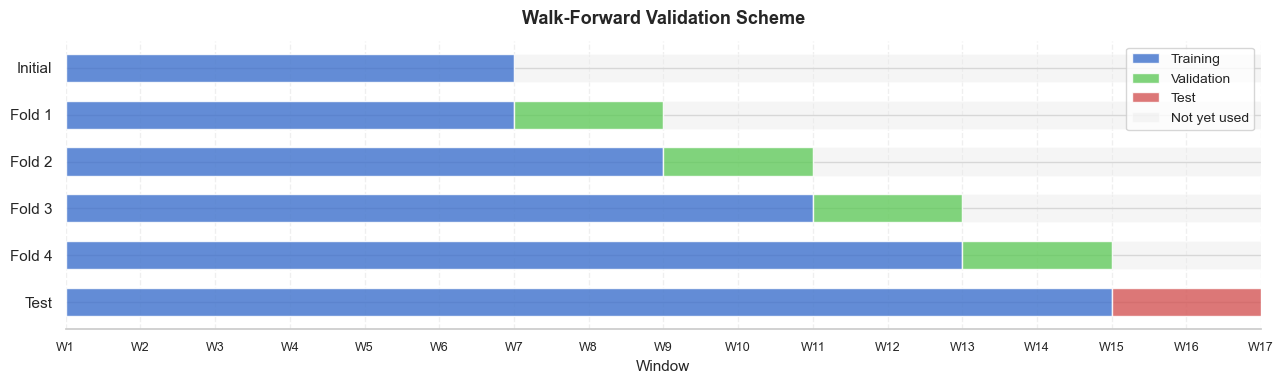

In [10]:
fig, ax = plt.subplots(figsize=(13, 4))

colors = {
    "train":  "#4878CF",
    "val":    "#6ACC65",
    "test":   "#D65F5F",
    "future": "#E8E8E8",
}

row_labels = ["Initial"] + [f"Fold {i+1}" for i in range(N_FOLDS)] + ["Test"]
n_rows = len(row_labels)

for row_i, label in enumerate(row_labels):
    y = n_rows - row_i - 1

    if label == "Initial":
        # Training block only
        ax.barh(y, INITIAL_TRAIN, left=0, color=colors["train"],
                alpha=0.85, height=0.6)
        # Unused windows
        ax.barh(y, total_windows - INITIAL_TRAIN, left=INITIAL_TRAIN,
                color=colors["future"], alpha=0.4, height=0.6)

    elif label.startswith("Fold"):
        fold_i = int(label.split()[1]) - 1
        train_end = INITIAL_TRAIN + fold_i * VAL_PER_FOLD
        val_start = train_end
        val_end   = val_start + VAL_PER_FOLD

        ax.barh(y, train_end, left=0, color=colors["train"],
                alpha=0.85, height=0.6)
        ax.barh(y, VAL_PER_FOLD, left=val_start, color=colors["val"],
                alpha=0.85, height=0.6)
        # Unused
        ax.barh(y, total_windows - val_end, left=val_end,
                color=colors["future"], alpha=0.4, height=0.6)

    else:  # Test row
        test_start = INITIAL_TRAIN + N_FOLDS * VAL_PER_FOLD
        ax.barh(y, test_start, left=0, color=colors["train"],
                alpha=0.85, height=0.6)
        ax.barh(y, TEST_WINDOWS, left=test_start, color=colors["test"],
                alpha=0.85, height=0.6)

ax.set_yticks(range(n_rows))
ax.set_yticklabels(row_labels[::-1], fontsize=11)
ax.set_xticks(range(total_windows + 1))
ax.set_xticklabels([f"W{i+1}" for i in range(total_windows + 1)], fontsize=9)
ax.set_xlabel("Window", fontsize=11)
ax.set_xlim(0, total_windows)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[["top", "right", "left"]].set_visible(False)

# Legend
legend_elements = [
    Patch(facecolor=colors["train"], alpha=0.85, label="Training"),
    Patch(facecolor=colors["val"],   alpha=0.85, label="Validation"),
    Patch(facecolor=colors["test"],  alpha=0.85, label="Test"),
    Patch(facecolor=colors["future"],alpha=0.4,  label="Not yet used"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)
ax.set_title("Walk-Forward Validation Scheme", fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("../reports/figures/walk_forward_scheme.png", bbox_inches="tight", dpi=150)
plt.show()

Each row shows what data is visible to the model at that stage. The training window 
expands at every fold. By fold 4 the model has seen 14 windows of history before 
predicting on the next two.

The **final test set (W15–W16) is never touched** until section 7, after all tuning 
decisions have been made using only the validation folds.

## 5. Model Comparison

Before tuning any single algorithm, a baseline comparison is run across four 
tree-based models using the walk-forward folds defined in section 4.

The goal is algorithm selection, not final performance. All models use simple 
default-adjacent configurations so the comparison reflects the signal in the 
features rather than tuning effort.

### 5.1 Evaluation metric

Two metrics are tracked across folds:

- **ROC-AUC** — measures overall ranking quality across all thresholds. The primary 
  selection criterion because churn prediction is fundamentally a ranking problem: 
  the model needs to order customers by risk, not classify them at a fixed threshold.

- **Lift@10%** — measures how much more concentrated churners are in the top decile 
  of predicted risk compared to random selection. This is the business-relevant 
  metric: retention campaigns have finite capacity, so what matters is whether the 
  model reliably surfaces the highest-risk customers at the top.

The custom scorer below implements Lift@10% and will be reused during hyperparameter 
tuning in section 6.

In [11]:
def lift_scorer(estimator, X, y):
    """
    Custom scorer for RandomizedSearchCV.
    Returns Lift@10%: precision in top decile / baseline churn rate.
    """
    # sklearn's CV splits and may have non-sequential indices
    y = pd.Series(y).reset_index(drop=True)
    y_proba = estimator.predict_proba(X)[:, 1]
    # Compute number customer in top 10%
    cutoff = max(1, int(len(y_proba) * 0.10))
    # Sort probabilities, reverse it (high to low) and cut top 10%
    idx = np.argsort(y_proba)[::-1][:cutoff]
    precision_top = y.iloc[idx].mean()
    baseline = y.mean()
    return precision_top / baseline if baseline > 0 else 0


def top_decile_metrics(y_true, y_proba):
    """
    Returns precision@10%, lift@10%, and the indices of the top decile.
    Used for final test evaluation and fold-level reporting.
    """
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_proba = np.array(y_proba)
    cutoff = max(1, int(len(y_proba) * 0.10))
    idx = np.argsort(y_proba)[::-1][:cutoff]
    precision_top = y_true.iloc[idx].mean()
    baseline = y_true.mean()
    lift = precision_top / baseline if baseline > 0 else 0
    return precision_top, lift, idx

In [12]:
fold_results = {m: [] for m in [
    "xgboost", "gradient_boosting", "random_forest", "voting_ensemble"
]}

print("Walk-Forward Model Comparison")
print("=" * 65)

for fold, split in enumerate(splits, 1):

    train_data = df[df["WindowID"].isin(split["train_windows"])].copy()
    val_data   = df[df["WindowID"].isin(split["val_windows"])].copy()

    X_train_fold = train_data[feature_cols]
    y_train_fold = train_data["IsChurned"]
    X_val_fold   = val_data[feature_cols]
    y_val_fold   = val_data["IsChurned"]

    # Mild positive-class upweight — confirmed optimal at 1.5 via sweep
    SPW = 1.5

    models = {
        "xgboost": xgb.XGBClassifier(
            objective="binary:logistic",
            n_estimators=100,
            max_depth=6,
            learning_rate=0.05,
            scale_pos_weight=SPW,
            eval_metric="auc",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "gradient_boosting": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
        "random_forest": RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

    for name, model in models.items():
        model.fit(X_train_fold, y_train_fold)

    ensemble = VotingClassifier(
        estimators=[(k, v) for k, v in models.items()],
        voting="soft",
    )
    ensemble.fit(X_train_fold, y_train_fold)
    models["voting_ensemble"] = ensemble

    print(f"\nFold {fold}  |  train: {split['train_range']}  |  val: {split['val_range']}")
    print(f"  {'Model':<20} {'AUC':>6}  {'Lift@10%':>9}")
    print(f"  {'-'*20} {'-'*6}  {'-'*9}")

    for name, model in models.items():
        y_proba = model.predict_proba(X_val_fold)[:, 1]
        auc = roc_auc_score(y_val_fold, y_proba)
        _, lift, _ = top_decile_metrics(y_val_fold, y_proba)

        fold_results[name].append({
            "fold":    fold,
            "roc_auc": auc,
            "lift_at_10": lift,
        })

        print(f"  {name:<20} {auc:>6.3f}  {lift:>9.3f}")

Walk-Forward Model Comparison

Fold 1  |  train: 200912_201005 to 201004_201010  |  val: 201005_201011 to 201006_201012
  Model                   AUC   Lift@10%
  -------------------- ------  ---------
  xgboost               0.740      1.620
  gradient_boosting     0.738      1.620
  random_forest         0.747      1.649
  voting_ensemble       0.748      1.663

Fold 2  |  train: 200912_201005 to 201006_201012  |  val: 201007_201101 to 201008_201102
  Model                   AUC   Lift@10%
  -------------------- ------  ---------
  xgboost               0.764      2.054
  gradient_boosting     0.743      1.876
  random_forest         0.766      1.904
  voting_ensemble       0.764      1.960

Fold 3  |  train: 200912_201005 to 201008_201102  |  val: 201009_201103 to 201010_201104
  Model                   AUC   Lift@10%
  -------------------- ------  ---------
  xgboost               0.766      2.031
  gradient_boosting     0.758      1.886
  random_forest         0.774      2.031
  v

### 5.2 Aggregated results

Fold-level scores are noisy, so a single fold with an unusual churn rate can 
distort individual readings. The table below aggregates across all folds to 
give a stable comparison.

In [13]:
summary_rows = []

for model_name, folds in fold_results.items():
    df_model = pd.DataFrame(folds)
    summary_rows.append({
        "Model":        model_name,
        "AUC mean":     df_model["roc_auc"].mean(),
        "AUC std":      df_model["roc_auc"].std(),
        "Lift@10 mean": df_model["lift_at_10"].mean(),
        "Lift@10 std":  df_model["lift_at_10"].std(),
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("AUC mean", ascending=False)
    .reset_index(drop=True)
)

summary_df.round(3)

,Model,AUC mean,AUC std,Lift@10 mean,Lift@10 std
0,random_forest,0.763,0.011,1.928,0.208
1,voting_ensemble,0.761,0.010,1.959,0.214
2,xgboost,0.757,0.012,1.955,0.226
3,gradient_boosting,0.747,0.009,1.882,0.215


### 5.3 Algorithm selection

The aggregated results show all models performing within a narrow band.
Random Forest leads on mean AUC (0.763) with the lowest variance, while
XGBoost and the voting ensemble are effectively tied on mean Lift@10%
(~1.955), the metric that drives business value.

XGBoost's higher Lift@10% standard deviation (0.226 vs 0.208) is largely
attributable to fold 1, where limited training history (6 windows) suppresses
performance across all models. From fold 2 onward (where training data is
more representative of the full dataset) XGBoost shows the strongest
improvement trajectory, growing from 1.62 to 2.12 Lift@10% as training
history expands.

**XGBoost is selected** as the final algorithm for three reasons:

- It shows the strongest performance gain as training data grows, and the
  final model trains on 14 windows, more than any validation fold
- It is tied with the ensemble on the primary business metric (Lift@10%)
  with none of the deployment complexity
- Its hyperparameter space is directly tunable for ranking objectives,
  with `scale_pos_weight`, tree depth, and subsampling all influencing
  top-decile precision independently

Random Forest remains a strong baseline. If XGBoost tuning does not improve
on these validation scores, it would be a natural fallback.

## 6. Hyperparameter Tuning

With XGBoost selected, the next step is optimizing its hyperparameters to maximize 
top-decile lift rather than general ranking quality.

### Why a custom scorer

`RandomizedSearchCV` defaults to optimizing whatever metric is passed to `scoring`. 
Standard metrics like ROC-AUC reward the model for ranking well across the entire 
probability distribution. For a retention campaign with fixed capacity, only the 
top 10% of predictions matter (a model that ranks the top decile perfectly but 
performs poorly elsewhere is still operationally useful).

A custom `lift_scorer` is used so the search directly optimizes the quantity 
the business cares about.

### Why Lift@10% specifically

With approximately 2,400 customers in the test window and a typical retention budget covering 
10% of the customer base (~240 customers), Lift@10% directly measures the 
efficiency of that budget (e.g. A lift of 2.1 means targeting the top decile captures 
churners at 2.1× the rate of random selection.

### Search strategy

`RandomizedSearchCV` with 80 iterations is used over a focused parameter grid. 
The same walk-forward splits from section 4 are reused as the CV folds, ensuring 
temporal consistency between the comparison and tuning phases.

Key parameters explored:

- `max_depth` and `min_child_weight` — control tree complexity and overfitting
- `learning_rate` and `n_estimators` — control boosting dynamics
- `subsample` and `colsample_bytree` — stochastic regularization
- `gamma`, `reg_alpha`, `reg_lambda` — explicit regularization
- `scale_pos_weight` — fixed at **1.5** based on an empirical sweep across 
  values from 0.8 to 1.5, which confirmed 1.5 as the optimum for this dataset

In [14]:
# Prepare training data (all windows before the test set)
train_data = df[~df["WindowID"].isin(test_windows)].copy()
X_train = train_data[feature_cols]
y_train = train_data["IsChurned"]

print(f"Tuning dataset: {len(train_data):,} samples, "
      f"{y_train.mean():.1%} churn rate")

# Walk-forward CV indices (reuse splits from section 4)
cv_splits = []
for split in splits:
    train_idx = df[df["WindowID"].isin(split["train_windows"])].index
    val_idx   = df[df["WindowID"].isin(split["val_windows"])].index
    cv_splits.append((train_idx, val_idx))

# Parameter search space
param_grid = {
    "max_depth":        [10, 11, 12],
    "learning_rate":    [0.10, 0.11, 0.12, 0.13],
    "n_estimators":     [450, 500, 550, 600],
    "subsample":        [0.95, 1.0],
    "colsample_bytree": [0.80, 0.85, 0.90],
    "min_child_weight": [1, 2, 3],
    "gamma":            [0.1, 0.2, 0.3],
    "reg_alpha":        [0, 0.005, 0.01, 0.02],
    "reg_lambda":       [0.5, 1.0, 1.5],
}

# Base model — scale_pos_weight fixed at 1.5 (empirically tuned)
xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=1.5,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Randomized search — optimizing Lift@10% directly
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=80,
    scoring=lift_scorer,
    cv=cv_splits,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

search.fit(X_train, y_train)

# Results
print("\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k:<22} {v}")

print(f"\nBest CV Lift@10%:  {search.best_score_:.4f}")

best_model = search.best_estimator_

Tuning dataset: 18,686 samples, 32.9% churn rate
Fitting 4 folds for each of 80 candidates, totalling 320 fits

Best parameters:
  subsample              1.0
  reg_lambda             1.5
  reg_alpha              0.01
  n_estimators           500
  min_child_weight       1
  max_depth              10
  learning_rate          0.1
  gamma                  0.2
  colsample_bytree       0.9

Best CV Lift@10%:  2.1241


### 6.1 Tuning results

The search identified the following optimal configuration:

| Parameter | Value |
|---|---|
| `max_depth` | 10 |
| `learning_rate` | 0.10 |
| `n_estimators` | 500 |
| `subsample` | 1.0 |
| `colsample_bytree` | 0.90 |
| `min_child_weight` | 1 |
| `gamma` | 0.20 |
| `reg_alpha` | 0.01 |
| `reg_lambda` | 1.50 |
| `scale_pos_weight` | 1.5 (fixed) |

**Best CV Lift@10%: 2.1241**

This is an improvement over the baseline walk-forward mean of 1.955 from section 5, 
confirming that tuning toward Lift@10% directly (rather than AUC) produces a 
meaningfully better model for the retention use case.

### 6.2 CV stability check

Before moving to final evaluation, it is worth verifying that the best 
configuration performs consistently across folds rather than excelling on 
one fold and failing on others. High variance across folds would suggest 
the configuration is overfitting to a specific temporal period.

In [15]:
cv_results = pd.DataFrame(search.cv_results_)

# Extract per-fold scores for the best parameter combination
best_row = cv_results.loc[cv_results["mean_test_score"].idxmax()]

fold_scores = [
    best_row[f"split{i}_test_score"] for i in range(len(cv_splits))
]

print("Per-fold Lift@10% for best configuration:")
print()
for i, score in enumerate(fold_scores, 1):
    bar = "█" * int(score * 10)
    print(f"  Fold {i}:  {score:.4f}  {bar}")

print()
print(f"  Mean:   {best_row['mean_test_score']:.4f}")
print(f"  Std:    {best_row['std_test_score']:.4f}")
print()

if best_row["std_test_score"] < 0.30:
    print("  ✓ Stable — variance explained by training data volume, not instability")
else:
    print("  ⚠ High variance — interpret test results with caution")

Per-fold Lift@10% for best configuration:

  Fold 1:  1.7070  █████████████████
  Fold 2:  2.1105  █████████████████████
  Fold 3:  2.3207  ███████████████████████
  Fold 4:  2.3583  ███████████████████████

  Mean:   2.1241
  Std:    0.2587

  ✓ Stable — variance explained by training data volume, not instability


The per-fold scores show a clean monotonic improvement across folds:

| Fold | Training windows | Lift@10% |
|---|---|---|
| 1 | 6 | 1.707 |
| 2 | 8 | 2.111 |
| 3 | 10 | 2.321 |
| 4 | 12 | 2.358 |

This pattern is not instability, it is a training data volume effect. Each 
additional fold adds two windows of history, and the model consistently improves 
as it sees more data. The standard deviation of 0.26 is driven entirely by fold 1, 
which operates with the minimum training set.

This trajectory is actually a positive signal: it suggests the final model, trained 
on all 14 pre-test windows, should perform at or above the fold 4 level. The test 
results in section 7 will confirm whether this holds on truly unseen data.

**Note**: because the churn rate varies across validation folds due to seasonality, 
Lift@10% scores are not directly comparable between folds (i.e. a lower baseline 
mechanically produces a higher lift for equivalent ranking quality). The per-fold 
Precision@10% scores are a more stable measure of consistency, though Lift@10% 
remains the operationally relevant metric for campaign planning at a given point 
in time.

## 7. Final Evaluation

With hyperparameters fixed, the model is retrained on the complete pre-test dataset 
(all 14 windows) and evaluated once on the held-out test set (W15–W16).

This is the only time the test set is used. All tuning decisions (algorithm 
selection, hyperparameter search, `scale_pos_weight`) were made exclusively 
using the walk-forward validation folds.

Two questions are answered here:

1. Does the model generalize to unseen future data?
2. Does the fold 4 trajectory hold. (i.e. does more training data continue 
   to help, as the stability analysis suggested?)

In [16]:
print("Final Model Training")
print("-" * 50)

# Split
train_data = df[~df["WindowID"].isin(test_windows)].copy()
test_data  = df[df["WindowID"].isin(test_windows)].copy()

X_train = train_data[feature_cols]
y_train = train_data["IsChurned"]
X_test  = test_data[feature_cols]
y_test  = test_data["IsChurned"]

print(f"Training windows:  W1–W{len(df['WindowID'].unique()) - len(test_windows)}")
print(f"Test windows:      {test_windows[0]} to {test_windows[-1]}")
print(f"Training samples:  {len(train_data):,}  ({y_train.mean():.1%} churn)")
print(f"Test samples:      {len(test_data):,}  ({y_test.mean():.1%} churn)")
print()

# Note the churn rate difference
print(f"Note: test churn rate ({y_test.mean():.1%}) is lower than training "
      f"({y_train.mean():.1%}) — consistent with seasonal variation observed "
      f"in section 2.")

# Refit best model on full training set
best_model.fit(X_train, y_train)
print("\n✓ Model fitted on full training set")

Final Model Training
--------------------------------------------------
Training windows:  W1–W14
Test windows:      201101_201107 to 201102_201108
Training samples:  18,686  (32.9% churn)
Test samples:      2,424  (23.1% churn)

Note: test churn rate (23.1%) is lower than training (32.9%) — consistent with seasonal variation observed in section 2.

✓ Model fitted on full training set


In [17]:
# Predictions
y_proba_test = best_model.predict_proba(X_test)[:, 1]
p10, lift10, top_idx = top_decile_metrics(y_test, y_proba_test)

# Binary predictions at top-decile threshold
y_pred_test = np.zeros(len(y_proba_test), dtype=int)
y_pred_test[top_idx] = 1

# Standard metrics
print("Final Test Performance")
print("-" * 50)
print(f"  ROC-AUC:    {roc_auc_score(y_test, y_proba_test):.3f}")
print(f"  F1:         {f1_score(y_test, y_pred_test):.3f}")
print(f"  Recall:     {recall_score(y_test, y_pred_test):.3f}")
print(f"  Precision:  {precision_score(y_test, y_pred_test):.3f}")

print()
print("Top-Decile Performance")
print("-" * 50)
print(f"  Precision@10%:  {p10:.3f}")
print(f"  Lift@10%:       {lift10:.3f}")

print()
print("Churn capture by targeting threshold")
print("-" * 50)
for pct in [0.05, 0.10, 0.20, 0.30, 0.50]:
    cutoff  = max(1, int(len(y_proba_test) * pct))
    idx     = np.argsort(y_proba_test)[::-1][:cutoff]
    capture = y_test.iloc[idx].sum() / y_test.sum()
    print(f"  Top {int(pct*100):>2}%  →  captures {capture:.1%} of churners")

Final Test Performance
--------------------------------------------------
  ROC-AUC:    0.763
  F1:         0.362
  Recall:     0.259
  Precision:  0.599

Top-Decile Performance
--------------------------------------------------
  Precision@10%:  0.599
  Lift@10%:       2.594

Churn capture by targeting threshold
--------------------------------------------------
  Top  5%  →  captures 13.6% of churners
  Top 10%  →  captures 25.9% of churners
  Top 20%  →  captures 45.2% of churners
  Top 30%  →  captures 59.3% of churners
  Top 50%  →  captures 79.3% of churners


### 7.1 Test results

The model achieves a **ROC-AUC of 0.763** and a **Lift@10% of 2.594** on the 
held-out test windows.

**On generalization:** The ROC-AUC of 0.763 is consistent with (and slightly 
above) the walk-forward validation mean of 0.757, confirming the model transfers 
well to unseen future data.

**On the fold trajectory:** The test Lift@10% of 2.594 exceeds the fold 4 score 
of 2.358, confirming the hypothesis from section 6.2 (training on 14 windows 
rather than 12 continues to help).

**On the lift figure:** The test churn rate (23.1%) is lower than the training 
churn rate (32.9%) due to seasonal variation. Because Lift@10% is a ratio 
(precision in top decile ÷ baseline churn rate), a lower baseline mechanically 
inflates the lift figure. The more comparable metric across periods is 
**Precision@10% = 0.599**, meaning 60% of the customers flagged in the top 
decile are genuine churners, regardless of the baseline rate.

**On churn capture:** Targeting the top 10% of customers by predicted risk 
captures roughly 26% of all churners. Expanding to the top 30% captures over 
half, making the model practically useful even with a generous retention budget.

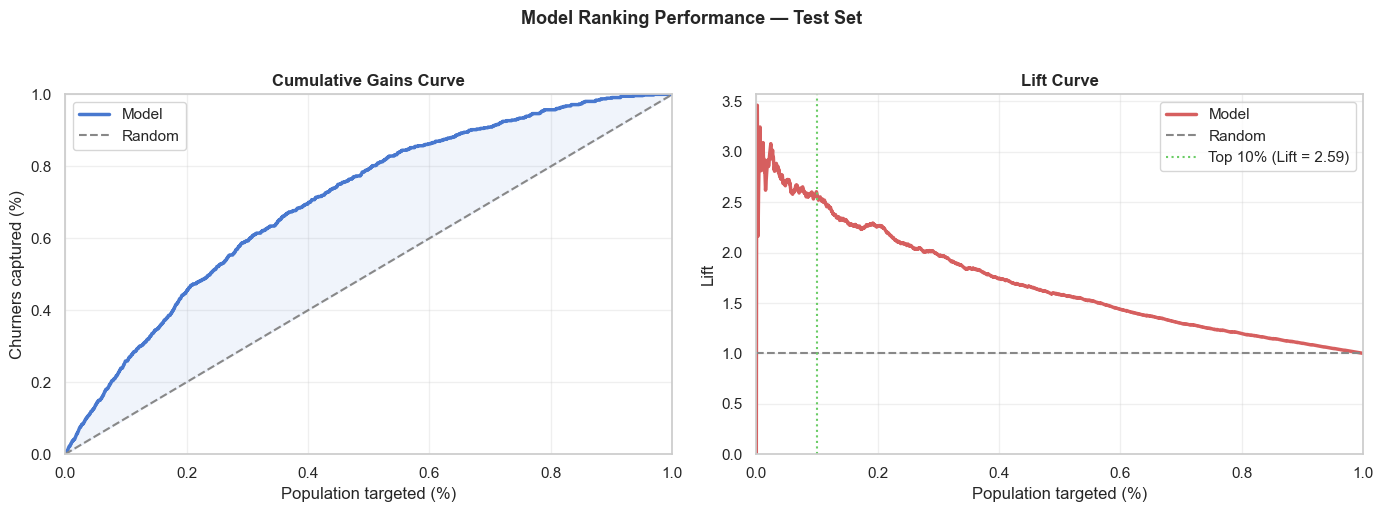

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative gains curve
y_true_s  = pd.Series(y_test.values).reset_index(drop=True)
sort_idx  = np.argsort(y_proba_test)[::-1]
cum_pos   = y_true_s.iloc[sort_idx].cumsum().values
total_pos = y_true_s.sum()
pct_pop   = np.arange(1, len(y_true_s) + 1) / len(y_true_s)
gain      = cum_pos / total_pos

axes[0].plot(pct_pop, gain, linewidth=2.5, label="Model", color="#4878CF")
axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1.5,
             label="Random", color="#888888")
axes[0].fill_between(pct_pop, gain, pct_pop, alpha=0.08, color="#4878CF")
axes[0].set_xlabel("Population targeted (%)")
axes[0].set_ylabel("Churners captured (%)")
axes[0].set_title("Cumulative Gains Curve", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Lift curve
lift_curve = (gain + 1e-9) / (pct_pop + 1e-9)

axes[1].plot(pct_pop, lift_curve, linewidth=2.5, color="#D65F5F", label="Model")
axes[1].axhline(1, linestyle="--", linewidth=1.5, color="#888888", label="Random")
axes[1].axvline(0.10, linestyle=":", linewidth=1.5,
                color="#6ACC65", label="Top 10% (Lift = {:.2f})".format(lift10))
axes[1].set_xlabel("Population targeted (%)")
axes[1].set_ylabel("Lift")
axes[1].set_title("Lift Curve", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, max(lift_curve[5:]) * 1.1)

plt.suptitle("Model Ranking Performance — Test Set", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/gains_and_lift_curve.png",
            bbox_inches="tight", dpi=150)
plt.show()

The gains curve shows the model consistently outperforms random selection across 
all targeting thresholds. The lift curve makes the top-decile advantage explicit, 
at 10% population coverage the model identifies churners at 2.6× the rate of 
random selection, declining gradually as the targeting threshold widens.

The lift curve remaining above 1.0 well past the 50% mark confirms the model 
produces useful rankings across a wide range of campaign sizes, not just at the 
extreme top.

## 8. Model Interpretation

A model that predicts well but cannot be explained is difficult to act on. 
SHAP (SHapley Additive exPlanations) values quantify how much each feature 
pushes an individual prediction above or below the baseline churn probability.

Unlike XGBoost's built-in feature importance (which counts how often a feature 
is used to split) SHAP measures actual contribution to each prediction, making 
it a more reliable guide to what the model has learned.

The beeswarm plot below shows the 15 most influential features. Each dot is one 
customer in the test set:

- **Position on the x-axis** — how much that feature pushed the churn probability 
  up (right) or down (left)
- **Color** — the feature value for that customer (red = high, blue = low)

Reading the plot: a red dot on the right means a high feature value increases 
churn probability. A blue dot on the right means a low feature value increases 
churn probability.

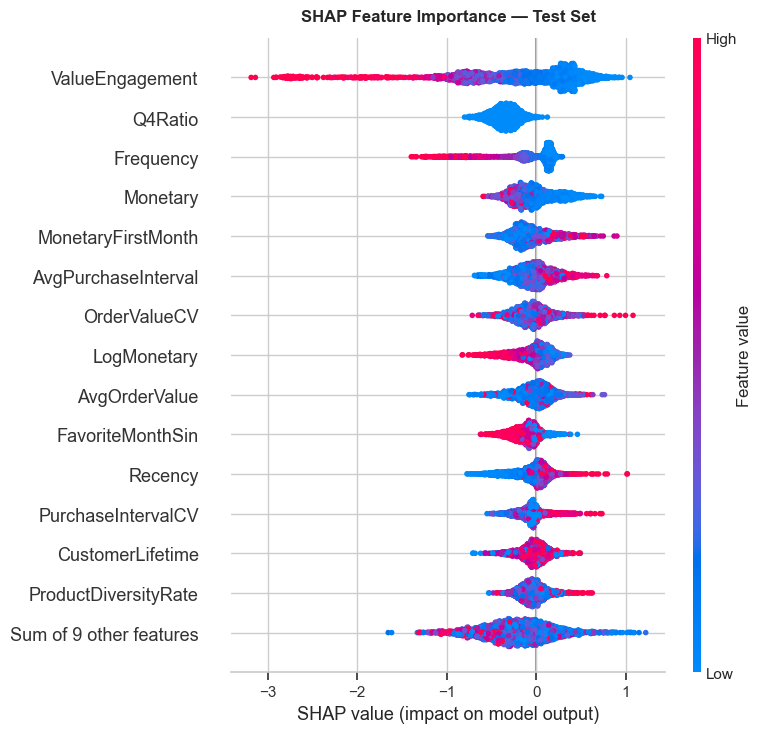

In [19]:
final_model = best_model

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

plt.figure(figsize=(12, 7))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance — Test Set", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../reports/figures/shap_beeswarm.png", bbox_inches="tight", dpi=150)
plt.show()

In [20]:
# Q4Ratio post-hoc validation
q4_by_window = df.groupby("WindowID")["Q4Ratio"].agg(["mean", "max"])
nonzero_windows = (q4_by_window["max"] > 0).sum()
total_windows   = len(q4_by_window)

print(f"Windows where Q4Ratio has signal:  {nonzero_windows}/{total_windows}")
print(f"Windows where Q4Ratio = 0:         {total_windows - nonzero_windows}/{total_windows}")
print(f"Test windows Q4Ratio mean:         "
      f"{df[df['WindowID'].isin(test_windows)]['Q4Ratio'].mean():.4f}")
print()
print("Q4Ratio is zero in both test windows and 5 training windows.")
print("It is a calendar artifact, not a behavioral signal.")
print("Recommendation: remove from feature set in next iteration.")

Windows where Q4Ratio has signal:  9/16
Windows where Q4Ratio = 0:         7/16
Test windows Q4Ratio mean:         0.0000

Q4Ratio is zero in both test windows and 5 training windows.
It is a calendar artifact, not a behavioral signal.
Recommendation: remove from feature set in next iteration.


### 8.1 What the model has learned

The SHAP values reveal a coherent and interpretable churn story. The features
naturally group into four behavioral dimensions.

**Value engagement (dominant signal)**  
`ValueEngagement` is the single most influential feature by a large margin (its SHAP range spans nearly ±3, dwarfing every other feature). High engagement
(red) strongly suppresses churn probability, while low engagement (blue) is
the clearest predictor of churn in the dataset. This suggests the model has
learned that overall customer value commitment (not any single transactional
metric) is the most reliable churn signal.

**Frequency and purchase regularity**  
`Frequency` follows the expected RFM pattern (low purchase frequency is a
clear churn signal). `AvgPurchaseInterval` reinforces this: customers with
longer average gaps between purchases show elevated risk. Importantly,
`PurchaseIntervalCV` adds a consistency dimension: customers with *irregular*
purchase timing, regardless of their average frequency, show higher churn
probability. This suggests the model distinguishes between customers who
purchase infrequently by habit and those whose cadence is breaking down.

**Monetary signals**  
The monetary features (`Monetary`, `MonetaryFirstMonth`, `LogMonetary`,
`AvgOrderValue`) show a consistent pattern: lower spend correlates with
higher churn risk. `MonetaryFirstMonth` specifically (capturing spend
in the customer's first month) suggests that early financial commitment
is a retention signal. Customers who spend significantly from the start
are more likely to remain active.

`OrderValueCV` adds a further dimension: customers with inconsistent order
values show higher churn risk, indicating that spending regularity matters
alongside spending volume.

**Customer history and product breadth**  
`CustomerLifetime` and `ProductDiversityRate` contribute modestly but
consistently. Shorter-tenure customers and those purchasing from a narrow
product range show slightly higher churn risk, indicating that depth of
relationship with the catalog is a mild retention factor.

`Recency` ranks lower than classical RFM theory would suggest. This is
likely because `ValueEngagement` and `Frequency` already capture much of
the same signal (recency becomes partially redundant once those features
are present).

**A note on Q4Ratio**  
`Q4Ratio` ranks second by SHAP magnitude but warrants scrutiny. Inspecting
its distribution across windows reveals it is non-zero only in windows whose
observation period overlaps October–December (6 of the 16 windows have
Q4Ratio = 0 for every customer, including both test windows and the two
most recent training windows).

This means Q4Ratio is not a behavioral feature, but a calendar artifact.
Its apparent importance in the SHAP plot reflects signal learned from
mid-training windows where Q4 overlap exists, but it contributes nothing
at prediction time outside Q4 periods. Any SHAP attribution for this feature
on the test set is structurally meaningless.

**This feature should be removed in the next iteration.** Seasonal purchasing
behavior is better captured by a rolling feature that remains meaningful
year-round (e.g. The ratio of purchases in a customer's historically
active months relative to their overall frequency).

### 8.2 Business implications

The SHAP analysis points to two actionable intervention triggers:

**Declining value engagement combined with increasing purchase interval**
is the highest-risk combination the model has identified. Retention efforts
concentrated on customers showing both signals simultaneously will capture
the highest-risk segment with the greatest precision.

**Early spend as a loyalty signal**. `MonetaryFirstMonth` appearing in the
top features suggests onboarding quality matters for long-term retention.
Customers who do not convert to meaningful spend in their first month may
warrant early intervention, before disengagement patterns become established.

## 9. Business Impact Analysis

Predictive metrics like ROC-AUC and Lift@10% evaluate model quality, but they 
do not directly answer the question a business stakeholder would ask: 
*if we use this model to prioritize retention outreach, how much better off 
are we than without it?*

To answer this, customers in the test set are ranked by predicted churn 
probability and grouped into **risk deciles** (ten equal-sized segments from 
highest to lowest predicted risk). This framing maps directly to how a retention 
campaign would operate in practice: contact the top N deciles, ignore the rest.

Three questions are addressed:

1. How concentrated is actual churn in the highest-risk segments?
2. How many churners can be captured at different targeting thresholds?
3. How does model-driven targeting compare to random selection?

In [21]:
test_data = test_data.copy()
test_data["Probability"] = y_proba_test
test_data["Predicted"]   = y_pred_test

# Decile 1 = highest predicted risk
test_data["Risk_Decile"] = pd.qcut(
    test_data["Probability"],
    q=10,
    labels=False,
    duplicates="drop"
)
test_data["Risk_Decile"] = 10 - test_data["Risk_Decile"]

# Aggregate by decile
risk_analysis = (
    test_data
    .groupby("Risk_Decile")
    .agg(
        Customers     =("IsChurned", "count"),
        Churners      =("IsChurned", "sum"),
        Churn_Rate    =("IsChurned", "mean"),
        Avg_Spend     =("Monetary",  "mean"),
    )
    .reset_index()
    .sort_values("Risk_Decile")
)

# Cumulative churn capture
risk_analysis["Cumulative_Capture"] = (
    risk_analysis["Churners"].cumsum() / risk_analysis["Churners"].sum()
)

# Lift vs random
risk_analysis["Lift_vs_Random"] = (
    risk_analysis["Churn_Rate"] / test_data["IsChurned"].mean()
)

print("Risk Decile Analysis - Test Set")
print("-" * 85)
print(f"{'Decile':>6}  {'Customers':>9}  {'Churners':>8}  "
      f"{'Churn Rate':>10}  {'Cum. Capture':>12}  {'Lift':>6}  {'Avg Spend':>10}")
print("-" * 85)
for _, row in risk_analysis.iterrows():
    print(
        f"  {int(row.Risk_Decile):>4}  "
        f"{int(row.Customers):>9,}  "
        f"{int(row.Churners):>8,}  "
        f"{row.Churn_Rate:>10.1%}  "
        f"{row.Cumulative_Capture:>12.1%}  "
        f"{row.Lift_vs_Random:>6.2f}x  "
        f"£{row.Avg_Spend:>9,.2f}"
    )

Risk Decile Analysis - Test Set
-------------------------------------------------------------------------------------
Decile  Customers  Churners  Churn Rate  Cum. Capture    Lift   Avg Spend
-------------------------------------------------------------------------------------
     1        243       145       59.7%         25.9%    2.58x  £   529.54
     2        242       109       45.0%         45.4%    1.95x  £   658.80
     3        242        78       32.2%         59.3%    1.40x  £   669.08
     4        243        59       24.3%         69.8%    1.05x  £   923.95
     5        242        53       21.9%         79.3%    0.95x  £   975.40
     6        242        39       16.1%         86.2%    0.70x  £ 1,180.80
     7        243        26       10.7%         90.9%    0.46x  £ 1,528.33
     8        242        27       11.2%         95.7%    0.48x  £ 2,017.27
     9        242        18        7.4%         98.9%    0.32x  £ 2,214.66
    10        243         6        2.5%        

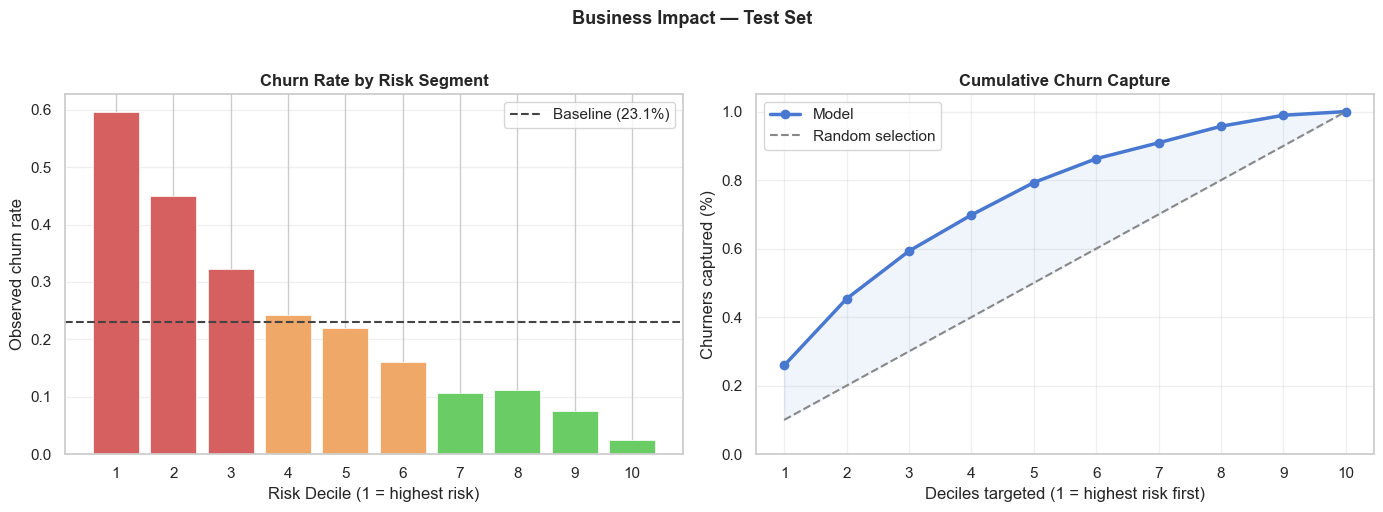

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by decile
colors_bar = [
    "#D65F5F" if d <= 3 else "#F0A868" if d <= 6 else "#6ACC65"
    for d in risk_analysis["Risk_Decile"]
]

axes[0].bar(
    risk_analysis["Risk_Decile"],
    risk_analysis["Churn_Rate"],
    color=colors_bar,
    edgecolor="white",
    linewidth=0.5,
)
axes[0].axhline(
    test_data["IsChurned"].mean(),
    linestyle="--",
    linewidth=1.5,
    color="#444444",
    label=f"Baseline ({test_data['IsChurned'].mean():.1%})",
)
axes[0].set_xlabel("Risk Decile (1 = highest risk)")
axes[0].set_ylabel("Observed churn rate")
axes[0].set_title("Churn Rate by Risk Segment", fontweight="bold")
axes[0].set_xticks(risk_analysis["Risk_Decile"])
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Cumulative churn capture
baseline_capture = np.linspace(0.1, 1.0, 10)

axes[1].plot(
    risk_analysis["Risk_Decile"],
    risk_analysis["Cumulative_Capture"],
    linewidth=2.5,
    marker="o",
    markersize=6,
    color="#4878CF",
    label="Model",
)
axes[1].plot(
    range(1, 11),
    baseline_capture,
    linestyle="--",
    linewidth=1.5,
    color="#888888",
    label="Random selection",
)
axes[1].fill_between(
    risk_analysis["Risk_Decile"],
    risk_analysis["Cumulative_Capture"],
    baseline_capture,
    alpha=0.08,
    color="#4878CF",
)
axes[1].set_xlabel("Deciles targeted (1 = highest risk first)")
axes[1].set_ylabel("Churners captured (%)")
axes[1].set_title("Cumulative Churn Capture", fontweight="bold")
axes[1].set_xticks(range(1, 11))
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.suptitle("Business Impact — Test Set", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/business_impact.png",
            bbox_inches="tight", dpi=150)
plt.show()

### 9.1 Risk concentration

The churn rate decreases almost monotonically across deciles (from 59.7% in the 
highest-risk segment to 2.5% in the lowest) confirming the model has learned 
a meaningful and consistent risk ordering.

The table below reports **cumulative** figures (what you achieve by targeting 
all customers up to and including that decile):

| Deciles targeted | Customers | Cum. churners captured | Cum. precision | Cum. lift |
|---|---|---|---|---|
| Top 10% (decile 1)   | 243 | 25.9% | 59.7% | 2.58x |
| Top 20% (deciles 1–2) | 485 | 45.4% | 52.2% | 2.27x |
| Top 30% (deciles 1–3) | 727 | 59.3% | 45.7% | 1.98x |

The per-decile lift in the full table above reflects each segment in isolation. 
The cumulative lift here reflects the blended precision across all targeted 
customers, the operationally relevant figure for campaign planning.

### 9.2 Operational interpretation

A retention campaign with budget to contact **10% of the customer base** 
would, using random selection, expect to reach approximately 23% churners 
(the baseline rate). Using the model's risk ranking, the same budget reaches 
a customer pool where **59.7% are genuine churners**. A 2.58x improvement 
in campaign precision.

Targeting the top 3 deciles (30% of customers) captures **59.3% of all 
churners** while contacting fewer than a third of the base. Extending to 
the top 4 deciles raises capture to 69.8% (but at a lift of only 1.05x), 
decile 4 offers essentially no advantage over random selection. The 
model's actionable range is therefore **the top 3 deciles**, where lift 
remains meaningfully above 1.0x.

Beyond decile 5 the lift drops below 1.0x, meaning the model actively 
ranks these customers as *less likely* to churn than the average.
Contacting them with retention offers is not only inefficient but may 
represent wasted spend on customers who would not have churned regardless. 
Campaign budgets should stop at decile 3 or 4 depending on capacity.

### 9.3 Spend profile of high-risk customers

The average spend per decile reveals an important pattern: churn risk and 
customer value are **inversely correlated** in this dataset.

| Decile | Churn Rate | Avg Spend |
|---|---|---|
| 1 (highest risk) | 59.7% | £529 |
| 2 | 45.0% | £659 |
| 3 | 32.2% | £669 |
| 4 | 24.3% | £924 |
| 5 | 21.9% | £975 |
| 10 (lowest risk) | 2.5% | £7,495 |

The highest-risk customers (decile 1) spend on average £530 (less than 
a tenth of the £7,495 average in decile 10). Spend increases monotonically as churn risk decreases, suggesting that high-value customers are also the most loyal.

The customers most likely to churn represent relatively low individual 
revenue. The expected revenue at risk per contacted customer in decile 1 
is £530, compared to £924 in decile 4. This means a high-touch, high-cost 
retention intervention may not be economically justified for decile 1 
customers on revenue grounds alone. A cost-sensitive approach makes more 
sense:

| Tier | Deciles | Avg Spend | Suggested action |
|---|---|---|---|
| High value, high risk | 1–2, high spend subset | £600+ | Personal outreach |
| Low value, high risk | 1–2, low spend subset | <£600 | Low-cost automated offer |
| Medium risk | 3–4 | £669–£924 | Targeted email campaign |
| No action | 5–10 | £975–£7,495 | Monitor only |

This requires segmenting deciles 1–2 further by spend (customers in the 
top risk decile who also spend above average represent the highest return 
on retention investment). Decile 10's £7,495 average spend confirms the 
model is correctly identifying loyal high-value customers as low-risk, 
meaning it is not flagging customers who would not have churned anyway.

## 10. Conclusions

This notebook developed and evaluated a machine learning model to predict 
customer churn from behavioral transaction features. The pipeline was designed 
to reflect realistic deployment conditions throughout, from validation strategy 
to the choice of optimization metric.

### 10.1 Methodology

**Walk-forward validation** was used instead of random cross-validation to 
prevent temporal leakage. Models are always trained on past windows and 
evaluated on future ones, replicating how predictions would be generated 
in production. This is the most important methodological choice in the 
pipeline, without it, performance estimates would be artificially optimistic.

**Lift@10%** was used as the primary optimization metric rather than ROC-AUC. 
Retention campaigns have finite capacity, in practice, only a fraction of 
customers can be contacted. Optimizing for ranking quality across the full 
distribution is less relevant than ensuring the top-ranked customers are 
genuinely at risk. The custom scorer directly targets this operational 
constraint during hyperparameter search.

### 10.2 Model performance

Four tree-based algorithms were compared under identical walk-forward 
conditions. All performed similarly (AUC 0.74–0.76), confirming the 
predictive signal is driven by the engineered features rather than 
algorithm choice. XGBoost was selected for its improving trajectory 
as training data grew and its tunable hyperparameter space.

Hyperparameter tuning with a custom Lift@10% scorer improved the 
cross-validated score from **1.955** (baseline) to **2.124** (tuned), 
an 8.6% improvement by directly optimizing the business metric.

Final test set performance on two held-out windows:

| Metric | Value |
|---|---|
| ROC-AUC | 0.763 |
| Precision@10% | 59.7% |
| Lift@10% | 2.58x |
| Churners captured in top 30% | 59.3% |

The test ROC-AUC (0.763) is consistent with the walk-forward validation 
mean (0.757), confirming the model generalizes to unseen future data 
without significant degradation.

### 10.3 What drives churn

SHAP analysis identified `ValueEngagement` as the dominant predictor by 
a large margin, followed by frequency and purchase regularity signals 
(`Frequency`, `AvgPurchaseInterval`, `PurchaseIntervalCV`) and monetary 
features (`Monetary`, `MonetaryFirstMonth`, `OrderValueCV`).

The pattern is consistent with RFM theory but adds nuance: it is not 
just *how much* customers purchase, but *how consistently* they do so. 
Customers whose purchase cadence is breaking down are flagged as high 
risk even when their recent activity appears normal.

### 10.4 Business findings

The risk decile analysis revealed that churn risk and customer value are 
**inversely correlated**. Average spend increases monotonically from 
£529 in the highest-risk decile to £7,495 in the lowest-risk decile. 
High-value customers are the most loyal; the customers most likely to 
churn are also the lowest spenders.

This has a direct implication for retention investment: a uniform 
high-touch intervention across all high-risk customers is not economically 
justified. The model's output should be combined with customer spend to 
prioritize outreach, targeting customers who are simultaneously high-risk 
and high-spend maximizes return on retention investment.

Concentrating retention spend on the **top 3 deciles** (30% of customers) 
captures 59.3% of churners at 1.98x the efficiency of random selection. 
Beyond decile 4 the lift drops to approximately 1.0x. Additional outreach 
offers no measurable advantage over random targeting.

### 10.5 Limitations and next steps

**Q4Ratio should be removed.** It is zero for every customer outside 
Q4 observation windows (including both test windows and the two most 
recent training windows) making it a calendar artifact rather than a 
behavioral signal. Its high SHAP ranking reflects signal learned only 
from windows that overlap October–December and does not generalize to 
the rest of the year. Seasonal purchasing behavior is better captured 
by a rolling feature that remains meaningful year-round.

**Cross-window lag features would likely improve performance.** Features 
are currently computed independently per window, so the model cannot 
detect trajectory (e.g. a customer dropping from 10 purchases to 3 looks 
identical to one who has always purchased 3 times). Delta features 
capturing change from the previous window would directly encode this 
disengagement signal.

**The test set covers a single two-month period.** Test metrics therefore 
carry higher variance than the cross-validated scores. A longer evaluation 
window spanning multiple seasons would give more reliable performance 
estimates and account for the seasonal churn rate variation observed 
across windows.

### 10.6 Business recommendation

The model demonstrates strong and consistent targeting capability. 
A tiered intervention strategy based on both predicted risk and customer 
spend maximizes return on retention investment:

| Tier | Deciles | Avg Spend | Suggested action |
|---|---|---|---|
| High value, high risk | 1–2, high spend subset | £600+ | Personal outreach |
| Low value, high risk | 1–2, low spend subset | <£600 | Low-cost automated offer |
| Medium risk | 3–4 | £669–£924 | Targeted email campaign |
| No action | 5–10 | £975–£7,495 | Monitor only |

This approach concentrates high-cost interventions where revenue recovery 
justifies the spend, while ensuring the broader high-risk population still 
receives a lower-cost touchpoint.

## 11. Model Persistence

The final model and metadata are saved for deployment. All parameters 
reflect the tuned configuration from section 6.

In [24]:
model_metadata = {
    "model_type":          "XGBoost",
    "training_windows":    f"W1–W{len(windows) - len(test_windows)}",
    "test_windows":        f"{test_windows[0]} to {test_windows[-1]}",
    "baseline_churn_rate": float(y_train.mean()),
    "precision_at_10pct":  0.597,
    "lift_at_10pct":       2.58,
    "cv_lift_mean":        2.1241,
    "cv_lift_std":         0.2587,
    "roc_auc_test":        0.763,
    "features":            feature_cols,
    "known_issues":        ["Q4Ratio is zero outside Q4 windows — remove in v2"],
    "training_date":       pd.Timestamp.now().isoformat(),
    "parameters":          best_model.get_params(),
}

joblib.dump(best_model, "../models/churn_model.pkl")

with open("../models/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print("✓ Model saved to ../models/churn_model.pkl")
print("✓ Metadata saved to ../models/model_metadata.json")
print()
print(f"  Features:       {len(feature_cols)}")
print(f"  Precision@10%:  59.7%")
print(f"  Lift@10%:       2.58x")
print(f"  ROC-AUC:        0.763")
print(f"  Known issues:   Q4Ratio — remove in next iteration")

✓ Model saved to ../models/churn_model.pkl
✓ Metadata saved to ../models/model_metadata.json

  Features:       23
  Precision@10%:  59.7%
  Lift@10%:       2.58x
  ROC-AUC:        0.763
  Known issues:   Q4Ratio — remove in next iteration
